# CS 503 Foundation Models: Part 1 - nanoGPT

In this part, we start by implementing the necessary building blocks to construct an autoregressive Transformer, like GPT.

#### Goals:

The goal of this first part is to familiarize yourself with the following topics:
- Causal attention
- Transformer decoder-only (e.g. GPT, LLaMA, ...) models
- Basic tokenization
- Basic positional encodings
- Autoregressive modelling on text and images
- Autoregressive inference

This notebook should give you a solid foundation of working with autoregressive Transformer models and get you "thinking with tokens".

If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the accompanying codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed.
- The notebooks are individual homework.

---

## 1 Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/home/kopidaki/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoGPT on TinyStories for text generation

In this exercise, we will implement a simplified autoregressive Transformer, similar to nanoGPT. 
We will train it on [TinyStories](https://arxiv.org/abs/2305.07759), a synthetically generated dataset of somewhat simple children's book stories. That focus allows us to train relatively small models that can generate coherent text and demonstrate some basic world knowledge.

### 2.1 Overview and tasks

To implement nanoGPT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

Hint: After completing the implementation of nanoGPT, in case you are still debugging, you may want to run the image generation examples in section 3 first. They are significantly faster to train and may facilitate faster debugging.

#### 2.1.1 MLP layer

In `nanofm.modeling.transformer_layers.Mlp`, implement the following two-layer Perceptron:

$$ \text{MLP}(X) = \text{GeLU}(X W_1^T + b_1) W_2^T + b_2 $$

Here, $\text{GeLU}$ denotes the [GeLU activation function](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html). 
The first linear layer projects x from dimension `in_features` to `hidden_features`, while the second projects it back to `out_features`.
Commonly, the bias terms are disabled. Make sure to take into account the `bias` argument.

#### 2.1.2 (Masked) self-attention layer

Next, we ask you to implement a layer that performs (optionally masked) multi-headed self-attention in `nanofm.modeling.transformer_layers.Attention`.

Remember the scaled dot-product attention formula:
$$ \text{Attention}(Q, K, V) = \text{softmax}_\text{row} \left( \frac{Q K^T}{\sqrt{d_k}} \right) V $$

The queries $Q$, the keys $K$, and the values $V$ are all linear projections of $X$:

$$ Q(X) = X W_Q^T $$
$$ K(X) = X W_K^T $$
$$ V(X) = X W_V^T $$

The scaling factor $d_k$ is the dimensionality of the keys $K$, i.e. `dim // num_heads`.

The attention is performed on `num_heads` heads in parallel (don't use a for loop) in `head_dim = dim // num_heads`-dimensional subspaces and the results are concatenated along the feature dimension.

In addition, we want to enable masking of the attention matrix, e.g. for implementing a Transformer decoder.
For this, the forward function takes an additional `mask` argument, specifying where to zero-out the attention matrix.
In practice, this is implemented by replacing the values of the attention matrix (pre softmax) to minus infinity wherever we don't want any attention flow.

#### 2.1.3 Transformer block

Next, implement a Transformer block in `nanofm.modeling.transformer_layers.Block`. It is defined as:

$$ X_a = X + \text{Attention}(\text{LN}(X)) $$
$$ X_b = X_a + \text{MLP}(\text{LN}(X_a)) $$

Here, $\text{LN}$ denotes (two separate) LayerNorm layers.

Don't forget to pass the optional mask to the self-attention layer!

#### 2.1.4 Assembling the blocks into a Transformer tunk

Now we have all the building blocks to create a Transformer trunk! 

In `nanofm.modeling.transformer_layers.TransformerTrunk`, create an `torch.nn.ModuleList` containing multiple Transformer blocks, and in the forward pass call them one after another.
Again, make sure to pass the mask!

#### 2.1.5 Initialize nanoGPT, implement the forward function, and loss (20 points)

Finally, we can use this Transformer trunk to build a nanoGPT model, which we implement in `nanofm.models.gpt.GPT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you just implemented.
4. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding, add the positional embedding (make sure to account for the length of the inputs!), pass it through the Transformer trunk, output normalization, and output projection.
2. When calling the Transformer trunk, make sure to pass a causal attention mask of shape (1, L, L), where L is the sequence length. The mask is of boolean type, and wherever it is False the attention is masked-out (i.e. set to -infinity), and otherwise it is left untouched. Remember the shape of the attention mask.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the padding token. We do not want to compute a loss on those.

#### 2.1.6 Write the generation loop (20 points)

Now we could theoretically train a model, but it would be of no use without a `generate` function. 
In this function you will run the model in a loop:
1. Given the context so far, run the forward function to get the logits. 
2. Extract the logits of only the last token (it's the next token prediction we care about). 
3. Sample from the probability distribution specified by the last token logits. You can use the helper function `nanofm.utils.sampling.sample_tokens` for that. Make sure to pass the temperature, top-k, and top-p arguments.
4. Concatenate the predicted next token with the context. This will be your new context for the next round. 
5. Respect the halting conditions: A) If you reach the maximum sequence length, stop generating. Take into account the length of the context so far! B) (Optional) In case you generate an `[EOS]` token corresponding to the end-of-sequence, stop generating early.
6. Finally after doing the entire loop and halting, return the sequence.

#### 2.1.7 Text tokenizer overview

For this part, you will not need to implement anything. This is to familiarize you with the text tokenizer we use.
A text tokenizer's job is to take any text and turn it into a sequence of integers (i.e. encode it) that we can predict autoregressively, and to then turn that original or a predicted sequence back into text.
Text tokenizers come in many shapes and forms, but commonly they turn subwords into a unique token, using a vocabulary of a pre-determined size. 

For nanoGPT, we will use the [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) tokenizer. It has a base vocabulary size of 50257, but we will add three more special tokens to it:
- `[PAD]`: Not all samples have the same length, but in order to batch them we need to equalize their lenght. The simplest way to do this is to pad the sequences up to some maximum sequence length, e.g. 256 tokens, using special `[PAD]` tokens. During training, we do not compute a loss on these tokens.
- `[SOS]`: The first token could just be the first token of the text sequence, but we want to be able to perform *unconditional* generation, i.e. we want to be able to generate the entire sequence and not have to give it a first token to start generating. The start-of-sequence token `[SOS]` serves as that marker. We prepend it to every sequence.
- `[EOS]`: Given that not all samples have the same length, we need a way for the model to indicate that it is done generating the next tokens. The end-of-sequence `[EOS]` token serves that purpose.

In [3]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

Let's see what happens when we encode sentences of variable length. Remember, we wrap the texts with an `[SOS]` (index 50258) and `[EOS]` (index 50259) token, and pad to the maximum sequence length with a `[PAD]` (index 50257) token. If a text is longer than the specified maximum sequence length, we truncate it.

In [4]:
texts = [
    'This is an example.',
    'Once upon a time there was a quick brown fox.',
]
tokens = tokenizer(texts, max_length=10, padding='max_length', truncation=True, return_tensors='pt')['input_ids']
tokens

tensor([[50258,  1212,   318,   281,  1672,    13, 50259, 50257, 50257, 50257],
        [50258,  7454,  2402,   257,   640,   612,   373,   257,  2068, 50259]])

We can use the same tokenizer to turn the sequences back into text:

In [5]:
for token_seq in tokens:
    print(tokenizer.decode(token_seq))

[SOS]This is an example.[EOS][PAD][PAD][PAD]
[SOS]Once upon a time there was a quick[EOS]


Let's define a helper function to filter out the special tokens:

In [6]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

In [7]:
for token_seq in tokens:
    print(token_ids_to_text(token_seq, text_tokenizer=tokenizer))

This is an example.
Once upon a time there was a quick


### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoGPT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoGPT/tinystories_d8w512.yaml
```

During training the script saves intermediate checkpoints at regular intervals. In case your training crashes, the training automatically resumes from that last checkpoint.
In case you don't want to resume training and instead start over from scratch, please either delete the checkpoint directory of that run (e.g. in `./outputs/nanoGPT/tinystories_d8w512/`) or rename it.

This training should take over one hour. You should reach a final validation loss around 1.3, and your loss curves should look something like the following:

<img src="./assets/nanoGPT_tinystories.png" alt="nanoGPT TinyStories loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your W&B account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/mynanoGPT_tinystories.png" alt="nanoGPT TinyStories loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [8]:
ckpt_path = './outputs/nanoGPT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [9]:
for _ in range(5):
    output = model.generate(context=[tokenizer.bos_token_id], temp=1.0, top_p=0.0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Tom loves to visit his grandpa, who lives in the city. Grandpa is a driver,inging down the street, walking with birds, and saying hello to everyone he sees. Tom likes to see the people and hear their stories, they clap and smile.

But Tom most favorite thing is to visit grandpa, as grandson might trucks. Grandpa drives up his winding road, holding a long bundle of boxes as he mentioning everything. He tells Tom all sorts of stories, but Tom misses grandpa every minute.Before grandpas, Tom asks, "Can grandpa drivers help me take grandpa colorful boxes? I want to take grandpa with me wherever he goes."

Grandpa smiles and says, "Yes, my dears, books and toys are very useful. But these places really over there is a lot of work to supply you with. That's why it is important to check it and increased this page."

Tom is curious and asks, "What'swhat work should I do with grandpa?" Grandpa thinks for a moment and says, "You can help him by spreading joy and joy to all of you."

Tom was fille

We don't have to generate the stories in a completely unconditional way. Let's try to probe the model and see if it learned some world knowledge. 
If we probe the model with the phrase `Daisy was hungry, so she`, we should expect a continuation talking about her getting food. 

In [10]:
context = tokenizer.encode('Daisy was hungry, so she')[:-1] # Encode and discard automatically added [EOS] token

for _ in range(5):
    output = model.generate(context=context, temp=1.0, top_p=0.0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
    print(token_ids_to_text(output, text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

Daisy was hungry, so she went and found some fruits from her garden. She picked them both up and split them between her fingers. She looked them and they were delicious.

She picked some of the fresh apples and shared them with her friends. All the children and her friends were so happy and they thanked Daisy.

The fruits were sweet and juicy. Daisy was so proud of herself and she even washed the apples. They licked her fingers and she gave them to all of her friends.

When she was finished, Daisy was still hungry. She split the fruit and shared it with her friends so that everyone was happy. They all enjoyed the sweet and juicy fruit, and Daisy was glad that everyone was full.

--------------------------------------------------

Daisy was hungry, so she went to the park to look for some food. She saw a jug filled with water, and she couldn't wait to taste it.

Daisy picked up the jug to take a drink. Suddenly, she heard a loud noise. It was coming from a man's house. He said, "Hey! Wh

### 2.5 Open-ended questions (5 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

- Q2.1: What effect does the temperature have on the generations?

    - A2.1: Temperature scales the logits before the softmax function, which controls the randomness of the predictions.
        A great way to understand the difference it makes is by testing it directly (see the coding cell below). Testing different temperatures brings very different results, specifically:

        - Low Temperature (T=0.5): As seen in the output, the story when we set a low temperature is coherent, grammatically correct, and logically sound. Lowering the temperature sharpens the probability distribution, making the model go with the safe, highly probable words.

        - High Temperature (T=2.0): When setting a high temperature, the output makes no sense. This is because bu setting a high temperature, the probability distribution is flattened and the model starts sampling highly improbable that might come from the "tail" of the distribution, which affects syntax and meaning as we can see by the example.

- Q2.2: What about the top_k and top_p parameters?

    - A2.2: Both are methods used to limit the number of potential tokens that the model can generate, but they behave differently to balance correctness and creativity:
    
        Top-K Sampling: Makes the model to only pick the $K$ most likely next tokens.
        -  When $K=1$ (Greedy Search), the model basically chooses the word that has the highest probability assigned to it which makes it the safest one. This results in a coherent start but eventually it falls into a permanent repetitive loop (See in the according code cell below: "She was so happy that she had escaped from the dog"). Greedy decoding lacks the stochasticity needed to break out of high-probability loops.

        - When $K=50$, the model could explore the top 50 choices. The output became more creative, and adds interesting twists to the story such as a pond, a crocodile, and berries. It avoided the repetitive loop but maintained grammatical and syntactical structure because it cuts off the extreme "tail" of bad words.
    
        Top-P Sampling: Dynamically limits the sampling pool to the smallest set of tokens whose cumulative probability exceeds the threshold $P$. 
        - When $P=0.1$, the threshold is so strict that it behaves identically to $K=1$. Because the top 1 or 2 words already make up 10% of the probability mass, the model falls back into greedy sampling and generates the exact same story about the dog. 

        - When $P=0.9$, the sampling pool is wider and this results in a creative plot about a park, a sand bowl, and a little girl. This method balances both creativity and coherence  because the amount of tokens shrinks automatically when the model is very confident (maintaining grammar) and expands when it isn't (which leads to creative plot twists).

- Q2.3: Sometimes the generations of this model are not very good. What could we do to improve it further?
    - A2.3: We built a standard GPT-2 style model and since then. there have been many advancements in autoregressive LLMs. Some things we could change n order to improve the current architecture are the following: 
            
        -  Change parts of the architecture such as changing the standard learned positional embeddings for Rotary Positional Embeddings (RoPE) [1], would give the model a much better understanding of relative distances between words.

        - Increasing the hidden dimensions, the number of attention heads, training for more epochs on a larger dataset and in general scaling up in terms of compute and data, would help the model learn longer term logical dependencies.

        - Using algorithms like Beam Search to explore multiple sentence branches simultaneously, evaluating the overall sequence probability rather than just the next word.

        - The GPT-2 tokenizer we are using is not optimized for our dataset. Training a custom BPE tokenizer directly on the TinyStories dataset might group common story phrases together more efficiently, reduce the sequence length and optimise the prediction task for the model.

        - Increase the size of the context window. Currently it is 256 tokens but if a story exceeds this length, the model cannot see the beginning of the story anymore, which causes logical gaps. Training on a larger context window would fix this memory bottleneck.

        - Right now, the model is only trained to predict the next word based on the dataset. We could add a second training phase using RLHF or DPO (Direct Preference Optimization) [2]. This would allow us to explicitly reward the model for generating text that is aligned to our preferences.

    [1] [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864) (Su et al. 2021)

    [2] [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290) (Rafailov et al. 2023)

In [11]:
# A2.1 - Temperature

context = tokenizer.encode('Daisy was hungry, so she')[:-1]

print("Low temperature (0.5)")
out_low = model.generate(context=context, temp=0.5, top_p=0.0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_low, text_tokenizer=tokenizer))

print("\nHigh temperature (2.0)")
out_high = model.generate(context=context, temp=2.0, top_p=0.0, top_k=0.0, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_high, text_tokenizer=tokenizer))

Low temperature (0.5)
Daisy was hungry, so she went to the kitchen to look for something to eat. She opened the cupboard and found some cereal. She smiled and grabbed the cereal.

Suddenly, Daisy heard a noise. It was her mom. She was holding a big bowl of cereal.

"Hi Daisy, what are you doing?" asked Mom.

"I'm eating cereal, Mommy!" said Daisy.

"That's nice, dear. Would you like to try some?" asked Mom.

Daisy nodded excitedly. Mom poured some of the cereal into the bowl and Daisy took a bite. It was delicious!

"Yum, this cereal is delicious!" said Daisy.

Mom smiled and said, "I'm glad you like it, Daisy. Now, let's go outside and play!"

Daisy smiled and ran outside to play with her friends.

High temperature (2.0)
Daisy was hungry, so she decided she mustaked waking hardlyattering for clockassembled Sinclair witnessing her OnSyriarows eagerly rum proposal hanging BALL matches Ships scams requesting paired theft Sasuke blogging Baltorts Phys55 assignmentsBooks Spit 373Dri Filipi

In [12]:
# A2.3 - Top-K sampling
context = tokenizer.encode('Daisy was hungry, so she')[:-1]

print("Top-K (K=1)")
out_k1 = model.generate(context=context, temp=1.0, top_p=0.0, top_k=1, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_k1, text_tokenizer=tokenizer))

print("\nTop-K (K=50)")
out_k50 = model.generate(context=context, temp=1.0, top_p=0.0, top_k=50, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_k50, text_tokenizer=tokenizer))

Top-K (K=1)
Daisy was hungry, so she went to the kitchen. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a noise. She looked around and saw a big dog. The dog was barking and running around the kitchen. Daisy was scared.

Daisy quickly grabbed the bowl and ran away. She ran and ran until she was safe. She was so happy that she had escaped from the dog.

Daisy was still hungry, so she went back to the kitchen. She opened the bowl and started to eat the cereal. She was so happy that she had escaped from the dog.

Top-K (K=50)
Daisy was hungry, so she went outside to look for something to eat. She heard a strange noise and thought it was coming from the pond where she lived. Daisy went closer to the pond to investigate.

When Daisy saw it, she could see a big, brown crocodile jumping out of the water. It waved its tail and made a loud noise. Daisy was scared and started to cry. She couldn't make the loud noise

In [13]:
# A2.3 - Top-P Sampling
context = tokenizer.encode('Daisy was hungry, so she')[:-1]

print("Top-P (P=0.1)")
out_p1 = model.generate(context=context, temp=1.0, top_p=0.1, top_k=0, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_p1, text_tokenizer=tokenizer))

print("\nTop-P (P=0.9)")
out_p9 = model.generate(context=context, temp=1.0, top_p=0.9, top_k=0, eos_idx=tokenizer.eos_token_id)[0]
print(token_ids_to_text(out_p9, text_tokenizer=tokenizer))

Top-P (P=0.1)
Daisy was hungry, so she went to the kitchen. She saw a big bowl of cereal on the table. She was so excited! She grabbed the bowl and started to eat.

Suddenly, Daisy heard a noise. She looked around and saw a big dog. The dog was barking and running around the kitchen. Daisy was scared.

Daisy quickly grabbed the bowl and ran away. She ran and ran until she was safe. She was so happy that she had escaped from the dog.

Daisy was still hungry, so she went back to the kitchen. She opened the bowl and started to eat the cereal. She was so happy that she had escaped from the dog.

Top-P (P=0.9)
Daisy was hungry, so she asked her mom if she could go to the park. Her mom said yes, so Daisy hopped in her car and off she went.

At the park, Daisy saw a big patch of sand. She was so excited that she ran over to it and started playing. She wanted to dig a deep hole and make a big mud pie.

But then Daisy heard someone shouting, "Hey! That's my sand bowl! You have to leave!" She tu

---

## 3 Training nanoGPT on MNIST for conditional image generation

In this part, we will train our nanoGPT on images, similar in spirit to [iGPT](https://openai.com/research/image-gpt).
What this means is that we turn images into a sequence of discrete tokens and train a decoder-only Transformer to perform next-token-prediction.
At inference time, we can then autoregressively generate new images from the training distribution, conditioned on the class label!

If you have successfully completed the nanoGPT implementation, you can directly re-use it for this step! The only thing we change is the way we represent the data.

### 3.1 Tokenization

First, we need to turn images into sequences of discrete tokens.

A common way of performing tokenization of images is to train a discrete VAE, such as [VQ-GAN](https://arxiv.org/abs/2012.09841) to autoencode images through a discrete bottleneck. This is an entire research field of its own, so we will not go further into that here.

Instead, we will tokenize the images in a much simpler way:
- First, we turn the grayscale images into black and white → each image is now a sequence of 14x14 zeros and ones. In this manner, we would already have a sequence of discrete tokens we could model, but the sequence length of 14x14=192 could be shorter.
- To reduce the sequence length further, we divide the image into 2x2 patches and turn each of the 2x2 patterns into a unique index. If we flatten each 2x2 patch into a sequence of 4 zeros and ones, we can directly interpret them as integers between 0 and 15. This reduces the sequence length by a factor of four. Much more manageable in our toy setting!

While this way of tokenizing is really quite "toy", it is indicative of a common problem when dealing with images and transformers: naively turning images to tokens can result in very large sequence lengths.

Let's plot some examples of the tokenized images. First is the original image, then we show each token, and finally we show the corresponding token sequence. 
The first token is the class-label, and the next 49 are the image tokens in raster-scan order. Their token id was shifted by 10 to account for the additional class token (we share the vocabulary with it).

/home/kopidaki/miniconda3/envs/nanofm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/kopidaki/miniconda3/envs/nanofm/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_

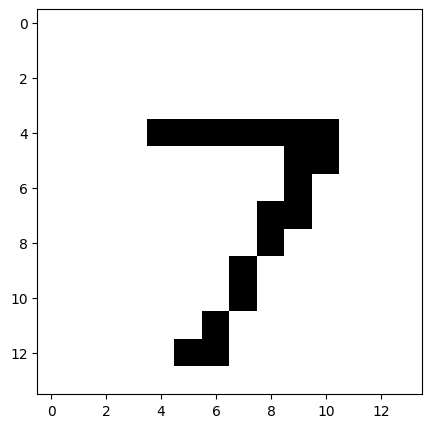

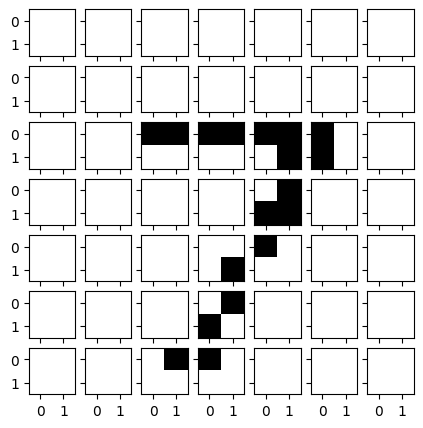

Tokens: tensor([ 7, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 22,
        22, 23, 20, 10, 10, 10, 10, 10, 17, 10, 10, 10, 10, 10, 11, 18, 10, 10,
        10, 10, 10, 16, 10, 10, 10, 10, 10, 14, 18, 10, 10, 10]) 




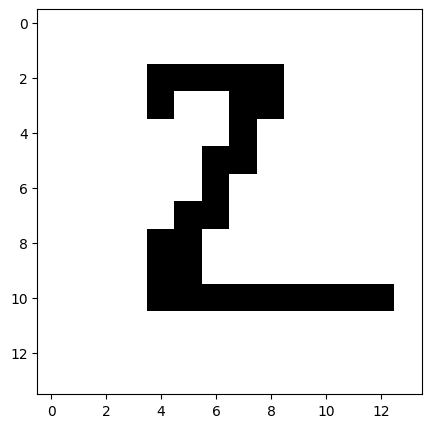

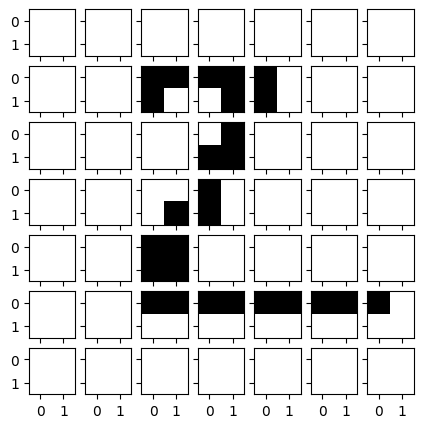

Tokens: tensor([ 2, 10, 10, 10, 10, 10, 10, 10, 10, 10, 24, 23, 20, 10, 10, 10, 10, 10,
        17, 10, 10, 10, 10, 10, 11, 20, 10, 10, 10, 10, 10, 25, 10, 10, 10, 10,
        10, 10, 22, 22, 22, 22, 18, 10, 10, 10, 10, 10, 10, 10]) 




In [14]:
data_loader = create_tokenized_mnist_dataloader(train=False, add_label_token=True, shuffle=False)
data_dict = next(iter(data_loader))

tokens = data_dict['input_ids']
reconst = detokenize_MNIST(tokens, patch_size=2, account_for_labels=True)
bits = rearrange(reconst, 'b (nh ph) (nw pw) -> b (nh nw) ph pw', ph=2, pw=2)

for i in range(2):
    plt.figure(figsize=(5., 5.)); plt.imshow(reconst[i], cmap='Greys'); plt.show()
    
    fig = plt.figure(figsize=(5., 5.))
    grid = ImageGrid(fig, 111, nrows_ncols=(7, 7), axes_pad=0.1)
    for j, img in enumerate(bits[i]):
        grid[j].imshow(img, cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
    print('Tokens:', tokens[i], '\n\n')

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoGPT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoGPT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. You should reach a final validation loss below 0.45, and your loss curves should look something like the following:

<img src="./assets/nanoGPT_mnist.png" alt="nanoGPT MNIST loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).
[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/mynanoGPT_mnist.png" alt="nanoGPT MNIST loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [15]:
ckpt_path = './outputs/nanoGPT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.

In [16]:
label = 5
output = model.generate(context=[label], temp=0.7, top_p=0.0)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 13, 13, 10, 10, 10, 10, 24,
         10, 10, 10, 10, 10, 10, 25, 14, 19, 10, 10, 10, 10, 10, 10, 10, 20, 10,
         10, 10, 10, 10, 11, 18, 10, 10, 10, 10, 14, 22, 10, 10]],
       device='cuda:0')

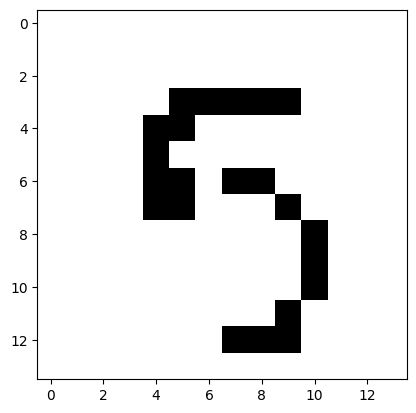

In [17]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

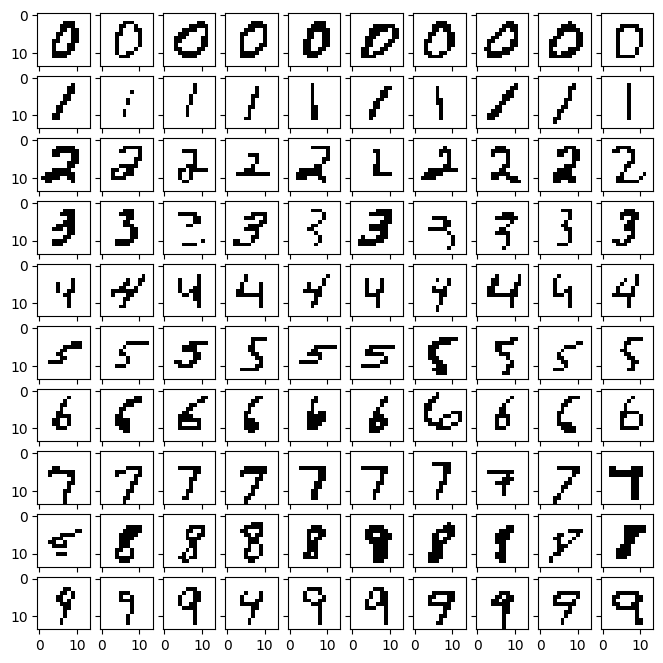

In [18]:
def generate_samples(model, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            output = model.generate(context=[label], temp=temp, top_p=top_p, top_k=top_k)
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, temp=0.7, top_p=0.9, top_k=0.0)

### 3.5 Open-ended questions (5 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

- Q3.1: What effect does the temperature have on the generations?

    - A3.1: According to the text genration, temperature controls the randomness of the generated image patches by scaling the logits before the softmax function is applied.

        - Low Temperature: As seen in the first image below the results are clean, sharp and recognizable as a low temperature sharpens the probability distribution, forcing the model to be highly confident and pick only the most likely patch combinations. However, this sacrifices diversity and makes many of the generated digits look almost identical to each other because the model doesn't take risks.

        - High Temperature: High temperature flattens the probability distribution. This causes the model to sample low-probability patches much more frequently. As shown in the coding cell below, this causes noise and scattered pixels. In many cases the digits lose their structure because the model is making too many random, low-confidence predictions.
    
        Interestingly there are instances in the low temperature case where it predicts too many white patches in a row, so the context ends up looking like an empty canvas, and the highest probability next token becomes another white patch. The model gets trapped in a repetitive loop (as we noticed in the text generation too) and generates a completely blank image. Higher temperatures prevent this by sometimes forcing the model to pick a lower-probability patch, breaking the loop.

- Q3.2: What about the top_k and top_p parameters?

    - A3.2: Top-K restricts the model to sample only from a fixed number of the most likely next patches.
    
        - Low Top-K: As seen in the first image, setting $K=1$ completely eliminates diversity. Every generated sample for a digit is identical the others. Also, we see the exact same blank background as we did with extremely low temperatures. The rows for '2' and '4' below, are completely empty. This is probably caused because greedy sampling forces the model to pick the most likely patch every single time, so if it starts by predicting white space, it gets trapped in a loop and never draws the digit.
            
        - High Top-K: The second image shows what happens when we allow the model to choose from the top 10 patches. The blank image problem is fixed and we have good diversity (for example the '4's, '7's, and '8's all have unique shapes). However, because our token vocabulary for MNIST is so small (only 26 possible tokens), allowing the model to pick the 10th best option means it frequently can pick bad patches. This shows up as noisy artifacts, floating dots etc.

        Top-P sampling dynamically restricts the pool to the smallest set of patches whose cumulative probability exceeds the threshold $P$.
            
        - Low Top-P: As seen in the first image from the according cell, this small threshold basically leads the model into greedy sampling behavior. It produces the exact same output as $K=1$: No variation between samples, and the same blank background loop where the model gets stuck drawing white spaces (as seen in the completely empty rows for '2' and '4'). Because the top 1 patch almost always holds more than 10% of the probability mass, the model never gets to consider alternative patches.
            
        - High Top-P: The second image of the according cell shows the behavior of Nucleus sampling with a higher P. It fixes the blank loop problem and brings diversity (for example the different loops in the '0's, '2's, and '8's). Because the pool size is smaller when the model is confident and bigger when it isn't, it does a much better job of avoiding the noisy artifacts we saw with $K=10$, though some artifacts can still happen if the model's confidence is very low.

- Q3.3: How might we extend this to text-to-image?
    - A3.3: 
        - We can keep the nanoGPT decoder-only architecture. We concatenate the text and the image into a single 1D sequence after tokenizing them: [BOS] <Text Tokens> [SEP] <Image Tokens> [EOS]. We train the model to predict the next token across this entire sequence. During inference, we feed it the text prompt and let it autoregressively generate the visual tokens.
        - We could use a text encoder to generate embeddings out of the text prompt. Then, upgrade our transformer blocks to include a Cross-Attention layer. During generation, the image tokens would act as the Queries to get relevant visual concepts from the text embeddings which would act as the Keys and Values.

Low temperature (T=0.5)


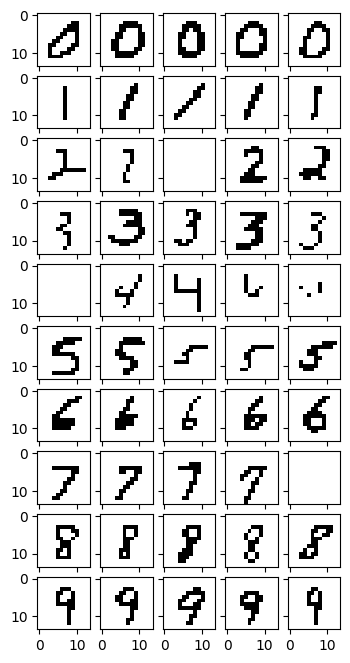

High temperature (T=2.0)


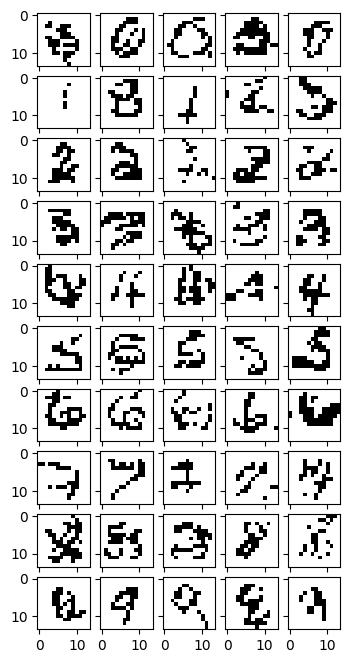

In [19]:
# A3.1 - Temperature

print("Low temperature (T=0.5)")
generate_samples(model, temp=0.5, top_p=0.0, top_k=0, n_samples=5)

print("High temperature (T=2.0)")
generate_samples(model, temp=2.0, top_p=0.0, top_k=0, n_samples=5)

Low top-k (K=1)


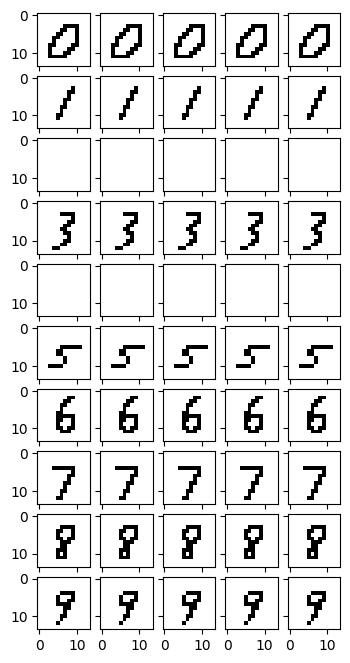

High top-k (K=10)


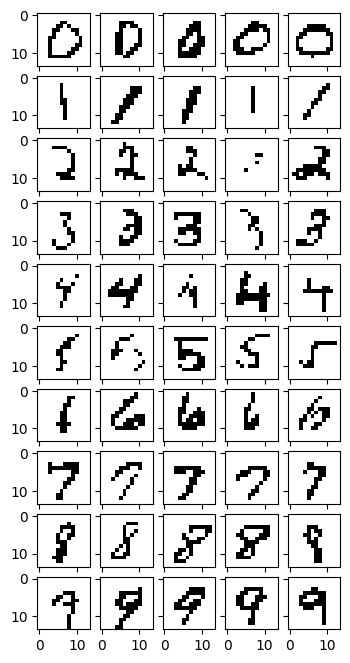

In [20]:
# A3.2 - Top-K Sampling

print("Low top-k (K=1)")
generate_samples(model, temp=1.0, top_p=0.0, top_k=1, n_samples=5)

print("High top-k (K=10)")
generate_samples(model, temp=1.0, top_p=0.0, top_k=10, n_samples=5)

Low top-p (P=0.1)


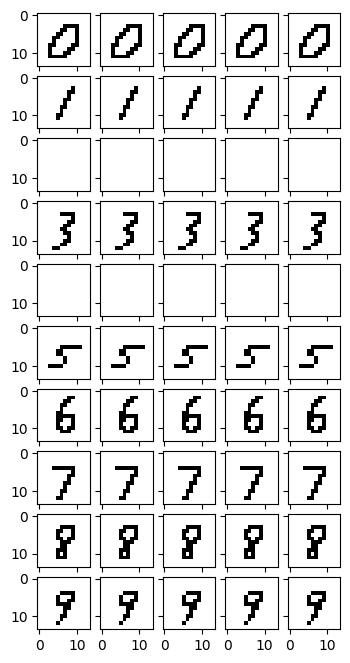

High top-p (P=0.9)


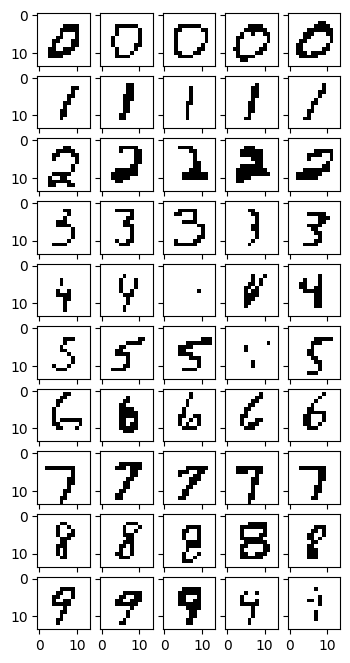

In [21]:
# A3.2 - Top-P Nucleus Sampling

print("Low top-p (P=0.1)")
generate_samples(model, temp=1.0, top_p=0.1, top_k=0, n_samples=5)

print("High top-p (P=0.9)")
generate_samples(model, temp=1.0, top_p=0.9, top_k=0, n_samples=5)

## 4 Further reading

Having implemented causal-attention, as well as a decoder-only Transformer, you should not have a hard time implementing cross-attention and a full encoder-decoder Transformer to train on arbitrary sequence-to-sequence tasks.
We will explore these topics in the next weeks.
That said, here is some further reading material should you want to dive deeper.

### 4.1 Papers & Blogs

- [Attention Is All You Need, Vaswani et al. 2017 (Original Transformer paper)](https://arxiv.org/abs/1706.03762)
- [Language Models are Unsupervised Multitask Learners, Radford et al. 2018 (GPT-2 paper)](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [Language Models are Few-Shot Learners, Brown et al. 2020 (GPT-3 paper)](https://arxiv.org/abs/2005.14165)
- [PaLM: Scaling Language Modeling with Pathways, Chrowdherry et al. 2022](https://arxiv.org/abs/2204.02311)
- [LLaMA: Open and Efficient Foundation Language Models, Touvron et al. 2023](https://arxiv.org/abs/2302.13971)
- [Llama 2: Open Foundation and Fine-Tuned Chat Models, Touvron et al. 2023](https://arxiv.org/abs/2307.09288)
- [The Llama 3 Herd of Models](https://arxiv.org/abs/2407.21783)
- [Scaling Laws for Neural Language Models, Kaplan et al. 2020](https://arxiv.org/abs/2001.08361)
- [Training Compute-Optimal Large Language Models, Hoffmann et al. (Chinchilla)](https://arxiv.org/abs/2203.15556)
- [Pixel Recurrent Neural Networks, Van den Oord et al. 2016 (PixelCNN)](https://arxiv.org/abs/1601.06759)
- [PixelCNN++: Improving the PixelCNN with Discretized Logistic Mixture Likelihood and Other Modifications, Salimans et al. 2017](https://arxiv.org/abs/1701.05517)
- [Zero-Shot Text-to-Image Generation, Ramesh et al. 2021 (DALL-E 1)](https://arxiv.org/abs/2102.12092)
- [Autoregressive Model Beats Diffusion: Llama for Scalable Image Generation, Sun et al. 2024 (Image generation with simple autoregressive models)](https://arxiv.org/abs/2406.06525)
- [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale, Dosovitskiy et al. 2020 (Vision Transformer paper)](https://arxiv.org/abs/2010.11929)
- [Transformer Circuits Thread](https://transformer-circuits.pub/)
- [The Transformer Family Version 2.0, Lilian Weng 2023](https://lilianweng.github.io/posts/2023-01-27-the-transformer-family-v2/)
- [The Illustrated Transformer, Jay Alammar 2018](https://jalammar.github.io/illustrated-transformer/)

### 4.2 Code bases

- [nanoGPT](https://github.com/karpathy/nanoGPT)
- [Llama model inference code](https://github.com/meta-llama/llama-models)
- [LlamaGen](https://github.com/FoundationVision/LlamaGen)
- [torchtitan](https://github.com/pytorch/torchtitan)
- [lingua](https://github.com/facebookresearch/lingua)

You might find that, in many ways, these repos are not that much different from what we implemented here!